In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]
all_features = analysis_run["feature_universe"]

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

In [2]:
annotations = ds.cells.fetch("clusters", key="I")
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)

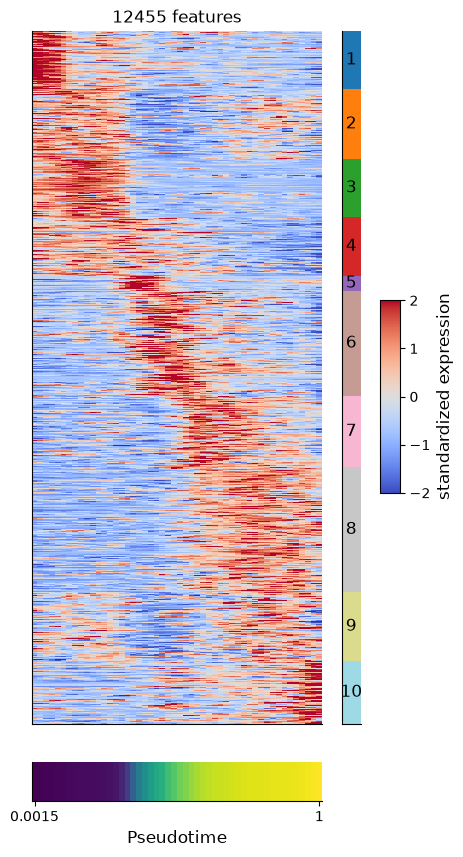

In [3]:
modules_ref = ds.run_pseudotime_aggregation(pseudotime_ref, features=all_features)
ds.plots.pseudotime_heatmap(aggregation=modules_ref)

In [4]:
modules = ds.load_pseudotime_aggregation(modules_ref)
module_genes = pd.DataFrame(
    {"gene": modules.feature_names, "module": modules.feature_clusters}
)
module_genes.groupby("module").size().rename("genes")

module
1     1049
2     1251
3     1048
4     1054
5      270
6     1886
7     1285
8     2242
9     1240
10    1130
Name: genes, dtype: int64

In [5]:
module_id = module_genes["module"].min()
module_genes.loc[module_genes["module"] == module_id, "gene"].head(20)

17              Mcm3
26             Prim2
52              Uxs1
65            Stk17b
70             Hspd1
71              Tyw5
75              Orc2
77             Trak2
93             Bard1
125         Serpine2
133              Ncl
139            Hjurp
152             Pask
156            Dtymk
177            Ddx18
183           Zranb3
184             Mcm6
208             Ipo9
214    2310009B15Rik
230             Dhx9
Name: gene, dtype: str